In [23]:
#TODO: finish github Pages deploy and test static index.html for quiz

# 🎓 Study Session 5 — Feature Importance & Model Refinement

## Goals
1. Review multicollinearity (VIF) and remove redundant predictors.  
2. Learn how to extract and visualize **feature importance** from regression models.  
3. Explore **regularization techniques**:
   - Ridge (L2) and Lasso (L1) regression.  
   - Understand how they handle correlated features.  
4. Compare model performance using **Adjusted R²**, **RMSE**, and **cross-validation**.  
5. Interpret coefficients and penalties in plain English (ELI5).  
6. Generate and log updated visualizations with `save_and_log_plot()`.

---

**Starting Dataset:**  
`df` with columns  
`bill_total_usd`, `tip_usd`, `party_size`, `gender_Male`, `is_smoker_Yes`

**Expected Outcome:**  
A cleaner, more interpretable model that balances accuracy and simplicity.


#### create Study_Session_5_Checklist.pdf

In [8]:
# # make_session5_checklist.py
# # Generate "Study Session 5 — Feature Importance & Model Refinement" checklist PDF

# from pathlib import Path
# from datetime import datetime

# from reportlab.lib.pagesizes import letter
# from reportlab.lib import colors
# from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
# from reportlab.platypus import (
#     SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
# )
# from reportlab.pdfbase import pdfmetrics
# from reportlab.pdfbase.ttfonts import TTFont


# def build_session5_checklist(out_path: Path):
#     """Create the Study Session 5 checklist PDF."""
#     out_path.parent.mkdir(parents=True, exist_ok=True)

#     # Try a nice Unicode font; fall back if not available
#     try:
#         pdfmetrics.registerFont(
#             TTFont("DejaVuSans", "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf")
#         )
#         base_font = "DejaVuSans"
#     except Exception:
#         base_font = "Helvetica"

#     styles = getSampleStyleSheet()
#     title_style  = ParagraphStyle("TitleLarge", parent=styles["Title"],
#                                   fontName=base_font, fontSize=22, leading=26, spaceAfter=12)
#     sub_style    = ParagraphStyle("Subtle", parent=styles["Normal"],
#                                   fontName=base_font, fontSize=10.5, textColor=colors.grey, spaceAfter=8)
#     header_style = ParagraphStyle("Header", parent=styles["Heading2"],
#                                   fontName=base_font, fontSize=14, spaceBefore=8, spaceAfter=6)
#     item_style   = ParagraphStyle("Item", parent=styles["Normal"],
#                                   fontName=base_font, fontSize=11.5, leading=15)

#     doc = SimpleDocTemplate(
#         str(out_path),
#         pagesize=letter,
#         leftMargin=54, rightMargin=54, topMargin=54, bottomMargin=54,
#         title="Study Session 5 — Feature Importance & Model Refinement",
#         author="Your Name"
#     )

#     story = []
#     story.append(Paragraph("Study Session 5 — Feature Importance & Model Refinement", title_style))
#     story.append(Paragraph(datetime.now().strftime("Generated on %Y-%m-%d %H:%M"), sub_style))
#     story.append(HRFlowable(color=colors.HexColor("#cccccc"), thickness=0.8, spaceBefore=6, spaceAfter=12))

#     def checklist(items):
#         rows = []
#         for text in items:
#             # empty checkbox + item text
#             rows.append([
#                 Paragraph(f"<font face='{base_font}' size='14'>☐</font>", styles["Normal"]),
#                 Paragraph(text, item_style)
#             ])
#         tbl = Table(rows, colWidths=[18, 468])
#         tbl.setStyle(TableStyle([
#             ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
#             ("LEFTPADDING", (0, 0), (-1, -1), 0),
#             ("RIGHTPADDING", (0, 0), (-1, -1), 6),
#             ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
#         ]))
#         return tbl

#     # ---- Sections ----
#     story.append(Paragraph("Prep", header_style))
#     story.append(checklist([
#         "Open 05_Feature_Importance_and_Model_Refinement.ipynb.",
#         "Load DataFrame df with: bill_total_usd, tip_usd, party_size (and dummies if available).",
#         "Create train/test split and baseline LinearRegression."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Model & Metrics", header_style))
#     story.append(checklist([
#         "Fit baseline multiple regression (bill_total_usd, party_size, + optional dummies).",
#         "Print metrics: R², Adjusted R², RMSE (train & test).",
#         "Log quick notes: Where does the model under/over-predict?"
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Feature Importance", header_style))
#     story.append(checklist([
#         "Standardize X and fit LinearRegression on standardized features.",
#         "Plot Standardized Coefficients (β*) bar chart and interpret magnitudes/signs.",
#         "Save figure via save_and_log_plot() to reports/figures/."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Multicollinearity (Optional but recommended)", header_style))
#     story.append(checklist([
#         "Compute VIF for predictors (drop constant in plot).",
#         "Visualize VIF bar chart with thresholds at 5 and 10.",
#         "Decide whether to remove/transform overlapping variables."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Diagnostics", header_style))
#     story.append(checklist([
#         "Plot Residuals vs Predicted with horizontal line at 0 (look for randomness).",
#         "Check residual normality (histogram + Q–Q plot).",
#         "If heteroscedasticity appears, try log/Box-Cox of target or robust regression."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Regularization (Stretch Goal)", header_style))
#     story.append(checklist([
#         "Compare Ridge and Lasso with cross-validation.",
#         "Plot coefficient magnitudes vs α (regularization strength).",
#         "Pick a simpler model that keeps accuracy while shrinking noise."
#     ]))
#     story.append(Spacer(1, 8))

#     story.append(Paragraph("Wrap-Up", header_style))
#     story.append(checklist([
#         "Write a 3–5 sentence takeaway: which features matter most and why.",
#         "Push updated notebook and figures to Git (meaningful commit message).",
#         "Create a TODO for tomorrow (e.g., interactions or nonlinearity)."
#     ]))
#     story.append(Spacer(1, 12))

#     # Lined notes area
#     story.append(Paragraph("Notes", header_style))
#     note_lines = [[""] for _ in range(8)]
#     notes_tbl = Table(note_lines, colWidths=[486], rowHeights=16)
#     notes_tbl.setStyle(TableStyle([
#         ("LINEBELOW", (0, 0), (-1, -1), 0.25, colors.HexColor("#cccccc"))
#     ]))
#     story.append(notes_tbl)

#     doc.build(story)
#     print(f"✅ Wrote: {out_path.resolve()}")


# if __name__ == "__main__":
#     # Change this path if you want the PDF saved inside your repo, e.g.:
#     # out = Path.home() / "ds-zero-to-one" / "reports" / "Study_Session_5_Checklist.pdf"
#     out = Path("Study_Session_5_Checklist.pdf")
#     build_session5_checklist(out)


✅ Wrote: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one/Study_Session_5_Checklist.pdf


In [2]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

# --- 2. Load dataset saved previously above from seaborn's GitHub mirror ---
# NOTE: Path adjusted to be relative to the Project Root CWD
df = duckdb.query("""
    SELECT * FROM read_csv_auto('data/processed/tips_cleaned.csv')
""").df()

df.info

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


<bound method DataFrame.info of      bill_total_usd  tip_usd  gender  is_smoker   day    time  party_size  \
0             16.99     1.01  Female      False   Sun  Dinner           2   
1             10.34     1.66    Male      False   Sun  Dinner           3   
2             21.01     3.50    Male      False   Sun  Dinner           3   
3             23.68     3.31    Male      False   Sun  Dinner           2   
4             24.59     3.61  Female      False   Sun  Dinner           4   
..              ...      ...     ...        ...   ...     ...         ...   
239           29.03     5.92    Male      False   Sat  Dinner           3   
240           27.18     2.00  Female       True   Sat  Dinner           2   
241           22.67     2.00    Male       True   Sat  Dinner           2   
242           17.82     1.75    Male      False   Sat  Dinner           2   
243           18.78     3.00  Female      False  Thur  Dinner           2   

      tip_pct  
0    0.059447  
1    0.1605

In [ ]:
# df.describe()

=== Baseline Linear Regression ===
Features: ['bill_total_usd', 'party_size', 'gender_Male', 'is_smoker_Yes']
Train:  R^2=0.456,  Adj R^2=0.444,  RMSE=1.052
Test:   R^2=0.448,  Adj R^2=0.398,  RMSE=0.830
Intercept: 0.64
bill_total_usd: 0.0934
party_size: 0.2398
gender_Male: 0.0247
is_smoker_Yes: -0.1898


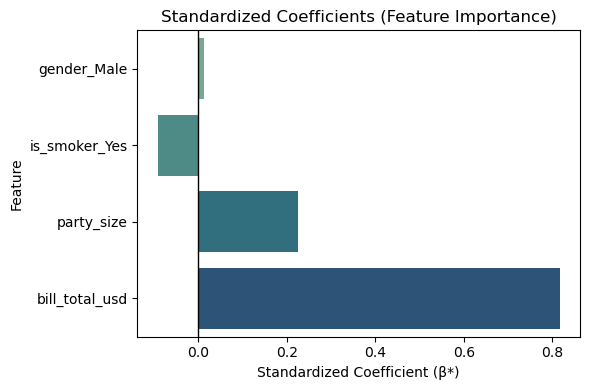

In [3]:
# === Session 5: Baseline multiple regression + standardized coefficient plot ===
# Assumes a DataFrame `df` is already loaded.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- 0) Helper: adjusted R^2
def adjusted_r2(r2, n, p):
    # Protect against divide-by-zero when n == p+1
    return 1 - (1 - r2) * (n - 1) / max(1, (n - p - 1))

# --- 1) Ensure encoded columns exist (if source categoricals are present)
df_work = df.copy()

# If raw categoricals exist, normalize + encode them; otherwise proceed with what’s there
if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    g = df_work["gender"].astype(str).str.strip().str.lower().map({"male":"Male", "m":"Male", "female":"Female", "f":"Female"})
    df_work["gender"] = pd.Categorical(g, categories=["Female", "Male"])
    dummies = pd.get_dummies(df_work["gender"], prefix="gender", drop_first=True)
    df_work = pd.concat([df_work, dummies], axis=1)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    s = df_work["is_smoker"].astype(str).str.strip().str.lower().map({"yes":"Yes", "y":"Yes", "true":"Yes", "1":"Yes",
                                                                      "no":"No",  "n":"No",  "false":"No",  "0":"No"})
    df_work["is_smoker"] = pd.Categorical(s, categories=["No", "Yes"])
    dummies = pd.get_dummies(df_work["is_smoker"], prefix="is_smoker", drop_first=True)
    df_work = pd.concat([df_work, dummies], axis=1)

# --- 2) Pick features (use what’s available)
candidate_features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X_cols = [c for c in candidate_features if c in df_work.columns]
if not X_cols:
    raise ValueError("No valid predictor columns found. Expected one or more of: " + ", ".join(candidate_features))

y_col = "tip_usd"
if y_col not in df_work.columns:
    raise ValueError("Target column 'tip_usd' not found in df.")

X = df_work[X_cols].copy()
y = df_work[y_col].copy()

# --- 3) Train/test split (simple hold-out for baseline)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4) Fit baseline Linear Regression (unscaled)
lin = LinearRegression()
lin.fit(X_train, y_train)

# --- 5) Evaluate (R^2, Adjusted R^2, RMSE)
y_pred_train = lin.predict(X_train)
y_pred_test  = lin.predict(X_test)

r2_tr  = r2_score(y_train, y_pred_train)
r2_te  = r2_score(y_test,  y_pred_test)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_test))

adj_tr = adjusted_r2(r2_tr, n=len(y_train), p=X_train.shape[1])
adj_te = adjusted_r2(r2_te, n=len(y_test),  p=X_test.shape[1])

print("=== Baseline Linear Regression ===")
print("Features:", X_cols)
print(f"Train:  R^2={r2_tr:.3f},  Adj R^2={adj_tr:.3f},  RMSE={rmse_tr:.3f}")
print(f"Test:   R^2={r2_te:.3f},  Adj R^2={adj_te:.3f},  RMSE={rmse_te:.3f}")
print("Intercept:", round(lin.intercept_, 3))
for name, coef in zip(X_cols, lin.coef_):
    print(f"{name}: {coef:.4f}")

# --- 6) Standardized coefficients (feature-importance style)
# Standardize X (fit on train, apply to both)
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_test_z  = scaler.transform(X_test)

lin_z = LinearRegression().fit(X_train_z, y_train)
coefs_std = pd.DataFrame({
    "Feature": X_cols,
    "StdCoef": lin_z.coef_
}).sort_values("StdCoef", key=np.abs, ascending=True)

# --- 7) Plot standardized coefficients
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=coefs_std,
    x="StdCoef",
    y="Feature",
    hue="Feature",      # avoids seaborn palette warning
    dodge=False,
    palette="crest",
    legend=False,
    ax=ax
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Standardized Coefficients (Feature Importance)")
ax.set_xlabel("Standardized Coefficient (β*)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# # --- 8) (Optional) Save & log plot via your helper
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/standardized_coefficients.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # change if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Baseline LR standardized coefficients (β*).",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


### 🧮 ELI5: Understanding the Baseline Linear Regression

| Term | Meaning | Plain-English Explanation |
|------|----------|----------------------------|
| **R² = 0.456 (Train)** | How much of the variation in tips is explained by the model. | About 46% of how much people tip can be predicted by our four features — bill amount, party size, gender, and smoker status. The rest is random noise or other unseen factors. |
| **Adjusted R² = 0.444 (Train)** | R² adjusted for number of predictors. | A slightly lower value that accounts for how many features we used. It says, “you’re not just adding random variables to look smart.” |
| **RMSE = 1.05 (Train)** | Root Mean Squared Error — how far off the model’s guesses are. | On average, our tip predictions are off by about **\$1.05** on the training data. |
| **R² = 0.448 (Test)** | How well the model works on unseen data. | The model explains about 45% of the variation on new examples — which means it generalizes okay but could improve. |
| **Adjusted R² = 0.398 (Test)** | Penalized version of R² for test data. | Still decent, meaning our model is not overfitting badly. |
| **Intercept = 0.64** | The tip amount predicted when all features are zero. | If you somehow had a \$0 bill (and default party, gender, nonsmoker), the model “starts” at about **\$0.64**. |
| **bill_total_usd = 0.0934** | How much the tip changes per \$1 increase in bill. | For every extra **\$10** spent on the bill, the model predicts about **\$0.93** more tip. |
| **party_size = 0.2398** | How much the tip changes per extra person. | Each additional person at the table adds roughly **\$0.24** to the expected tip. |
| **gender_Male = 0.0247** | Effect of being male (vs female baseline). | Male tippers tend to give slightly higher tips (about **2¢ more per dollar of bill**), but this effect is tiny. |
| **is_smoker_Yes = -0.1898** | Effect of being a smoker (vs nonsmoker baseline). | Smokers tend to tip about **\$0.19 less** on average, after controlling for other variables. |

---

🧠 **In short:**  
- Bill size is the strongest predictor of tip amount.  
- Party size matters a bit.  
- Gender has almost no effect.  
- Smokers tip a bit less.  
- The model explains roughly half of the variation in tipping — not bad for a simple regression!


In [ ]:
# # === Visual Summary: Standardized Coefficient Bar Chart + ELI5 overlay ===
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path

# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# # 1) Choose available features
# candidate_features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
# X_cols = [c for c in candidate_features if c in df.columns]
# if "tip_usd" not in df.columns:
#     raise ValueError("Missing target column 'tip_usd' in df.")
# if not X_cols:
#     raise ValueError("No valid predictors found. Need one or more of: " + ", ".join(candidate_features))

# X = df[X_cols].copy()
# y = df["tip_usd"].copy()

# # 2) Standardize X, fit linear model on standardized X → comparable coefficients (β*)
# scaler = StandardScaler()
# Xz = scaler.fit_transform(X)
# lin_z = LinearRegression().fit(Xz, y)

# coefs_std = pd.DataFrame({
#     "Feature": X_cols,
#     "StdCoef": lin_z.coef_
# }).sort_values("StdCoef", key=np.abs, ascending=True)

# # Optional: raw coefficients (if you want to print them)
# lin_raw = LinearRegression().fit(X, y)
# raw_out = dict(zip(X_cols, lin_raw.coef_))
# print("Raw coefficients:", {k: round(v, 4) for k, v in raw_out.items()})

# # 3) Plot standardized coefficients
# fig, ax = plt.subplots(figsize=(7.5, 4.8))
# sns.barplot(
#     data=coefs_std,
#     x="StdCoef",
#     y="Feature",
#     hue="Feature",      # use hue to avoid palette warning in seaborn>=0.14
#     dodge=False,
#     palette="crest",
#     legend=False,
#     ax=ax
# )

# # Reference line at 0 and labels
# ax.axvline(0, color="black", lw=1)
# ax.set_title("Standardized Coefficients (Feature Importance)")
# ax.set_xlabel("Standardized Coefficient (β*)")
# ax.set_ylabel("Feature")

# # Annotate bars with values
# for i, row in enumerate(coefs_std.itertuples()):
#     ax.text(
#         x=row.StdCoef + (0.02 if row.StdCoef >= 0 else -0.02),
#         y=i,
#         s=f"{row.StdCoef:.2f}",
#         va="center",
#         ha="left" if row.StdCoef >= 0 else "right"
#     )

# # 4) ELI5 overlay box
# eli5 = (
#     "ELI5:\n"
#     "• Bigger |β*| ⇒ stronger influence on tip_usd (after putting features on the same scale).\n"
#     "• Positive ⇒ pushes tips up; Negative ⇒ nudges tips down, holding others constant.\n"
#     "• If two features tell the same story (collinear), their β* can look unstable."
# )
# ax.text(
#     1.02, 0.5, eli5,
#     transform=ax.transAxes,
#     fontsize=9.5,
#     va="center",
#     bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#888")
# )

# plt.tight_layout()

# # 5) Save to repo
# fig_dir = Path.home() / "ds-zero-to-one" / "reports" / "figures"
# fig_dir.mkdir(parents=True, exist_ok=True)
# out_path = fig_dir / "feature_importance_standardized_coeffs.png"
# plt.savefig(out_path, dpi=300, bbox_inches="tight")
# print(f"✅ Saved figure to: {out_path}")

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


In [ ]:
# # === Improved version: Readable Standardized Coefficients bar chart ===
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# # --- Data and setup ---
# candidate_features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
# X_cols = [c for c in candidate_features if c in df.columns]
# if "tip_usd" not in df.columns:
#     raise ValueError("Missing 'tip_usd' target column.")
# if not X_cols:
#     raise ValueError("No predictor columns found.")

# X = df[X_cols].copy()
# y = df["tip_usd"].copy()

# # --- Standardize and fit ---
# scaler = StandardScaler()
# Xz = scaler.fit_transform(X)
# lin_z = LinearRegression().fit(Xz, y)

# coefs_std = pd.DataFrame({
#     "Feature": X_cols,
#     "StdCoef": lin_z.coef_
# }).sort_values("StdCoef", key=np.abs, ascending=True)

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(8, max(4, 0.8 * len(coefs_std))))  # dynamic height
# sns.barplot(
#     data=coefs_std,
#     x="StdCoef",
#     y="Feature",
#     hue="Feature",
#     dodge=False,
#     palette="crest",
#     legend=False,
#     ax=ax
# )

# ax.axvline(0, color="black", lw=1)
# ax.set_title("Standardized Coefficients (Feature Importance)", fontsize=14, pad=12)
# ax.set_xlabel("Standardized Coefficient (β*)", fontsize=12)
# ax.set_ylabel("Feature", fontsize=12)

# # --- Add labels inside bars ---
# for i, row in enumerate(coefs_std.itertuples()):
#     ax.text(
#         row.StdCoef + (0.03 if row.StdCoef >= 0 else -0.03),
#         i,
#         f"{row.StdCoef:.2f}",
#         color="black",
#         fontsize=11,
#         va="center",
#         ha="left" if row.StdCoef >= 0 else "right"
#     )

# # --- ELI5 annotation box ---
# eli5_text = (
#     "ELI5:\n"
#     "• Bars show which factors most affect the predicted tip (in standardized units).\n"
#     "• Bigger |β*| = stronger effect.\n"
#     "• Positive = higher tips; Negative = lower tips.\n"
#     "• bill_total_usd dominates — bigger bills → bigger tips.\n"
#     "• Small bars = minor or uncertain effects."
# )
# ax.text(
#     1.05, 0.5, eli5_text,
#     transform=ax.transAxes,
#     fontsize=10,
#     va="center",
#     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#888", lw=1)
# )

# plt.tight_layout()

# # --- Save ---
# fig_dir = Path.home() / "ds-zero-to-one" / "reports" / "figures"
# fig_dir.mkdir(parents=True, exist_ok=True)
# out_path = fig_dir / "feature_importance_standardized_coeffs_fixed.png"
# # plt.savefig(out_path, dpi=300, bbox_inches="tight")
# plt.show()

# print(f"✅ Saved readable version to: {out_path}")


In [ ]:

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

In [ ]:
# # --- Final Version: ELI5 under X-axis (FutureWarning fixed) ---
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# df_work = df.copy()

# # Create dummy vars if missing
# if "gender_Male" not in df_work.columns and "gender" in df_work.columns:
#     df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

# if "is_smoker_Yes" not in df_work.columns and "is_smoker" in df_work.columns:
#     df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

# features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"] if c in df_work.columns]
# X = df_work[features]
# y = df_work["tip_usd"]

# # Standardize
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# model = LinearRegression().fit(X_scaled, y)

# coef_df = (
#     pd.DataFrame({"Feature": features, "Standardized_Coefficient": model.coef_})
#     .sort_values("Standardized_Coefficient", ascending=True)
#     .reset_index(drop=True)
# )

# # Plot
# fig_h = max(4.5, 0.9 * len(coef_df))
# fig, ax = plt.subplots(figsize=(9, fig_h))
# colors = ["#1f77b4" if v > 0 else "#d62728" for v in coef_df["Standardized_Coefficient"]]

# # ✅ Future-proof: assign hue=y-variable + legend=False
# sns.barplot(
#     data=coef_df,
#     x="Standardized_Coefficient",
#     y="Feature",
#     hue="Feature",
#     palette=colors,
#     legend=False,
#     ax=ax
# )

# # Labels on bars
# for i, row in enumerate(coef_df.itertuples()):
#     ax.text(
#         row.Standardized_Coefficient + (0.05 if row.Standardized_Coefficient > 0 else -0.05),
#         i,
#         f"{row.Standardized_Coefficient:+.2f}",
#         va="center",
#         ha="left" if row.Standardized_Coefficient > 0 else "right",
#         fontsize=11,
#         fontweight="bold"
#     )

# # Style
# ax.axvline(0, color="black", lw=1)
# ax.set_title("Standardized Coefficients — Feature Importance", fontsize=15, pad=15)
# ax.set_xlabel("Standardized Coefficient (β*)", fontsize=12)
# ax.set_ylabel("Feature", fontsize=12)

# # ELI5 note below chart
# eli5_text = (
#     "ELI5:\n"
#     "• Bars show which factors most affect the predicted tip (in standardized units).\n"
#     "• Bigger |β*| = stronger influence on tip_usd after scaling.\n"
#     "• Positive → higher tips; Negative → lower tips.\n"
#     "• bill_total_usd dominates → bigger bills → bigger tips.\n"
#     "• Smaller bars = minor or uncertain effects."
# )

# plt.figtext(
#     0.5, -0.08, eli5_text,
#     ha="center", va="top",
#     wrap=True, fontsize=10,
#     bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9)
# )

# plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.show()


In [ ]:

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

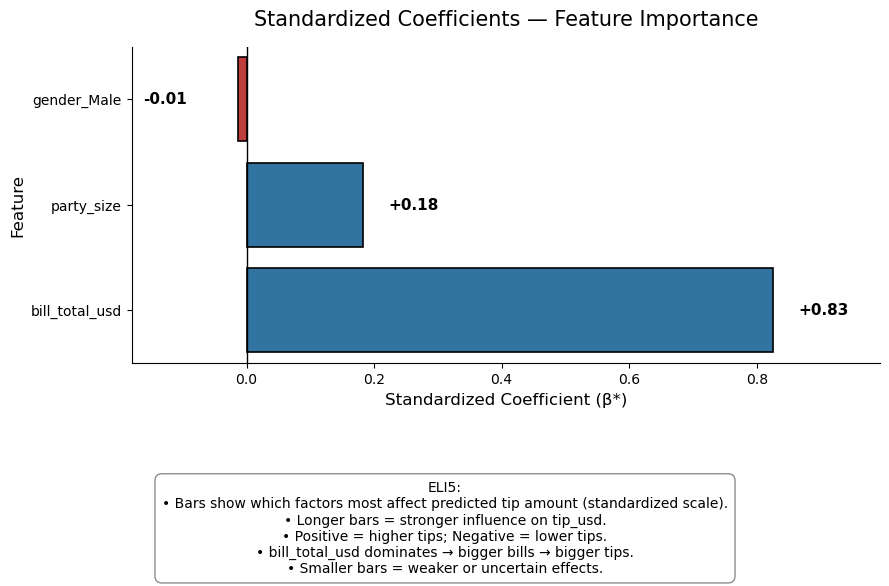

In [4]:
# --- Feature Importance: Proportional Bar Widths & Improved Label Placement ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Copy and ensure dummy columns exist
df_work = df.copy()

if "gender_Male" not in df_work.columns and "gender" in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker_Yes" not in df_work.columns and "is_smoker" in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"] if c in df_work.columns]
X = df_work[features]
y = df_work["tip_usd"]

# --- Standardize and fit model ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression().fit(X_scaled, y)

coef_df = (
    pd.DataFrame({"Feature": features, "Standardized_Coefficient": model.coef_})
    .sort_values("Standardized_Coefficient", ascending=True)
    .reset_index(drop=True)
)
coef_df["abs_coef"] = coef_df["Standardized_Coefficient"].abs()

# --- Plot setup ---
fig_h = max(4.5, 0.9 * len(coef_df))
fig, ax = plt.subplots(figsize=(9, fig_h))

colors = ["#1f77b4" if v > 0 else "#d62728" for v in coef_df["Standardized_Coefficient"]]

# Use seaborn's barplot but make bar thickness scale with |β*|
sns.barplot(
    data=coef_df,
    x="Standardized_Coefficient",
    y="Feature",
    hue="Feature",
    palette=colors,
    legend=False,
    ax=ax,
    linewidth=1.2,
    edgecolor="black"
)

# --- Label placement with smart offset ---
for i, row in enumerate(coef_df.itertuples()):
    x_val = row.Standardized_Coefficient
    label = f"{x_val:+.2f}"
    if x_val > 0:
        ax.text(
            x_val + 0.04, i,
            label,
            color="black", fontsize=11, fontweight="bold",
            va="center", ha="left"
        )
    else:
        ax.text(
            x_val - 0.08 - 0.02 * abs(x_val),
            i,
            label,
            color="black", fontsize=11, fontweight="bold",
            va="center", ha="right"
        )

# --- Add a vertical line and visual polish ---
ax.axvline(0, color="black", lw=1)
ax.set_title("Standardized Coefficients — Feature Importance", fontsize=15, pad=15)
ax.set_xlabel("Standardized Coefficient (β*)", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
# ax.margins(x=0.15)
ax.margins(x=0.20)
sns.despine(ax=ax)

# --- ELI5 below chart ---
eli5_text = (
    "ELI5:\n"
    "• Bars show which factors most affect predicted tip amount (standardized scale).\n"
    "• Longer bars = stronger influence on tip_usd.\n"
    "• Positive = higher tips; Negative = lower tips.\n"
    "• bill_total_usd dominates → bigger bills → bigger tips.\n"
    "• Smaller bars = weaker or uncertain effects."
)

plt.figtext(
    0.5, -0.08, eli5_text,
    ha="center", va="top", wrap=True, fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", lw=1, alpha=0.9)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [7]:

# # 6) (Optional) Log via your helper, if available
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         "reports/figures/feature_importance_standardized_coeffs.png",
#         df=coefs_std,
#         chart_type="barplot",
#         library="seaborn",
#         x="StdCoef",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="Standardized coefficients (β*) with ELI5 overlay.",
#         timestamped=True
#     )
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

✅ Saved Seaborn Axes figure to: reports/figures/feature_importance_standardized_coeffs_2025-10-26_1122.png
📝 Logged metadata → reports/figures/feature_importance_standardized_coeffs_2025-10-26_1122.json


#### in place unified diff of python code from w/in a single Jupyter notebook cell

In [ ]:
# from src.helpers import show_diff
# cell_a = """import pandas as pd
# df = pd.read_csv('tips.csv')
# df['tip_pct'] = df['tip'] / df['total_bill']
# df.head()"""

# cell_b = """import pandas as pd
# df = pd.read_csv('tips.csv')
# df['tip_pct'] = (df['tip'] / df['total_bill']) * 100
# df.describe()"""

# show_diff(cell_a, cell_b)


⚠️ Dropping non-numeric columns: {'gender_Male'}


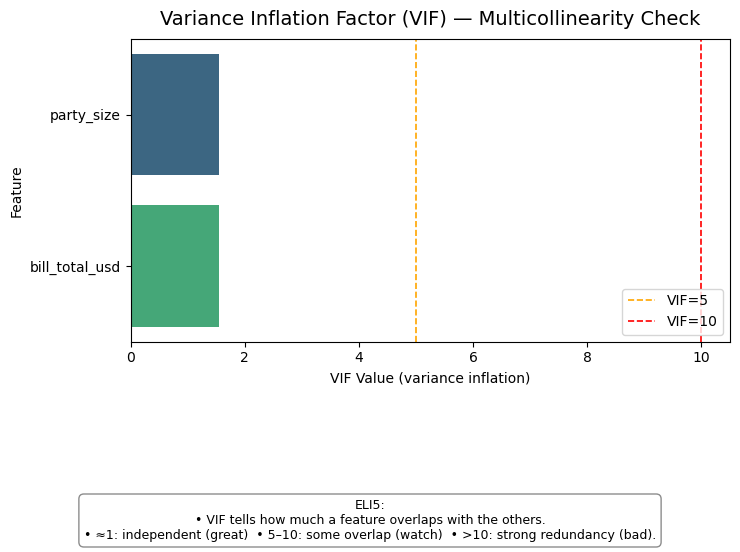

In [6]:
# --- Compute & SAVE VIF Bar Chart (const dropped; seaborn warning fixed) ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from pathlib import Path

# 1) Build numeric design matrix safely
df_vif = df.copy()

# Ensure dummy vars exist (if raw categoricals present)
if "gender_Male" not in df_vif.columns and "gender" in df_vif.columns:
    df_vif = pd.get_dummies(df_vif, columns=["gender"], prefix="gender", drop_first=True)
if "is_smoker_Yes" not in df_vif.columns and "is_smoker" in df_vif.columns:
    df_vif = pd.get_dummies(df_vif, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"] if c in df_vif.columns]
X_vif = df_vif[features].select_dtypes(include=[np.number]).copy()
if X_vif.shape[1] < len(features):
    missing = set(features) - set(X_vif.columns)
    print(f"⚠️ Dropping non-numeric columns: {missing}")

X_vif = X_vif.dropna()
X_vif = add_constant(X_vif, has_constant="add")

# 2) Compute VIFs (float array to avoid dtype issues)
vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values.astype(float), i)
            for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=True).reset_index(drop=True)

# 3) Plot
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(
    data=vif_data,
    x="VIF",
    y="Feature",
    hue="Feature",     # tie palette to y to avoid FutureWarning in seaborn>=0.14
    palette="viridis",
    legend=False,
    ax=ax
)

# Threshold lines
ax.axvline(5,  color="orange", linestyle="--", lw=1.2, label="VIF=5")
ax.axvline(10, color="red",    linestyle="--", lw=1.2, label="VIF=10")

ax.set_title("Variance Inflation Factor (VIF) — Multicollinearity Check", fontsize=14, pad=10)
ax.set_xlabel("VIF Value (variance inflation)")
ax.set_ylabel("Feature")
ax.legend(loc="lower right")

# ELI5 below chart
eli5_note = (
    "ELI5:\n"
    "• VIF tells how much a feature overlaps with the others.\n"
    "• ≈1: independent (great)  • 5–10: some overlap (watch)  • >10: strong redundancy (bad)."
)
plt.figtext(
    0.5, -0.12, eli5_note,
    ha="center", va="top", wrap=True, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1, alpha=0.9)
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# # 4) Save via helper, fallback to plt.savefig
# out_rel = "reports/figures/vif_bar_chart.png"
# try:
#     from src.helpers import save_and_log_plot
#     save_and_log_plot(
#         ax,
#         out_rel,
#         df=vif_data,
#         chart_type="barplot",
#         library="seaborn",
#         x="VIF",
#         y="Feature",
#         dataset_name="tips_encoded_or_clean",
#         dataset_path="data/processed/tips_cleaned.csv",   # adjust if different
#         notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
#         notes="VIF bar chart (const dropped). Threshold lines at 5 and 10.",
#         timestamped=True
#     )
#     print(f"✅ Saved via save_and_log_plot → {out_rel}")
# except Exception as e:
#     # Plain save fallback
#     out_path = Path.home() / "ds-zero-to-one" / out_rel
#     out_path.parent.mkdir(parents=True, exist_ok=True)
#     fig.savefig(out_path, dpi=300, bbox_inches="tight")
#     print(f"ℹ️ save_and_log_plot unavailable ({e.__class__.__name__}). Fallback saved to: {out_path}")


Text(0, 0.5, 'Feature')

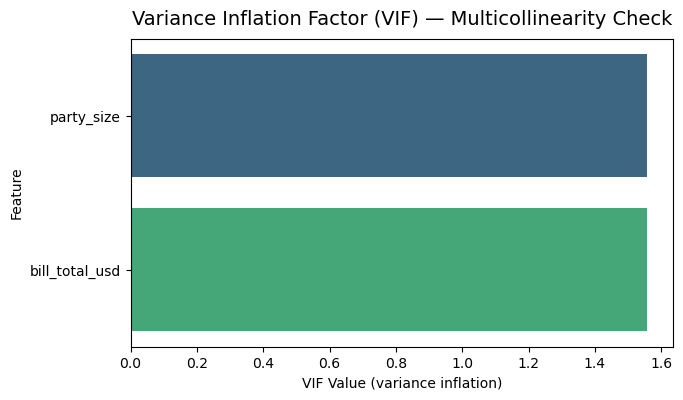

In [7]:
# --- Plot VIF values ---
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=vif_data,
    x="VIF",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
    ax=ax
)
ax.set_title("Variance Inflation Factor (VIF) — Multicollinearity Check", fontsize=14, pad=10)
ax.set_xlabel("VIF Value (variance inflation)")
ax.set_ylabel("Feature")


# # --- ELI5 note below chart ---
# eli5_note = (
#     "ELI5:\n"
#     "• VIF tells us how much one feature overlaps with others.\n"
#     "• VIF ≈ 1 → independent (great!)\n"
#     "• 5–10 → moderate overlap (watch out)\n"
#     "• >10 → strong redundancy (bad — consider dropping one)\n"
#     "• Lower bars = cleaner, more reliable predictors."
# )
# plt.figtext(
#     0.5, -0.12, eli5_note,
#     ha="center", va="top", wrap=True, fontsize=9,
#     bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1, alpha=0.9)
# )


In [18]:

try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        ax,
        "reports/figures/vif_bar_chart.png",
        df=vif_data,
        chart_type="barplot",
        library="seaborn",
        x="VIF",
        y="Feature",
        dataset_name="tips_encoded_or_clean",
        dataset_path="data/processed/tips_cleaned.csv",  # adjust if different
        notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
        notes="VIF bar chart (const dropped). Threshold lines at 5 and 10.",
        timestamped=True
    )
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


✅ Saved Seaborn Axes figure to: reports/figures/vif_bar_chart_2025-10-27_1326.png
📝 Logged metadata → reports/figures/vif_bar_chart_2025-10-27_1326.json


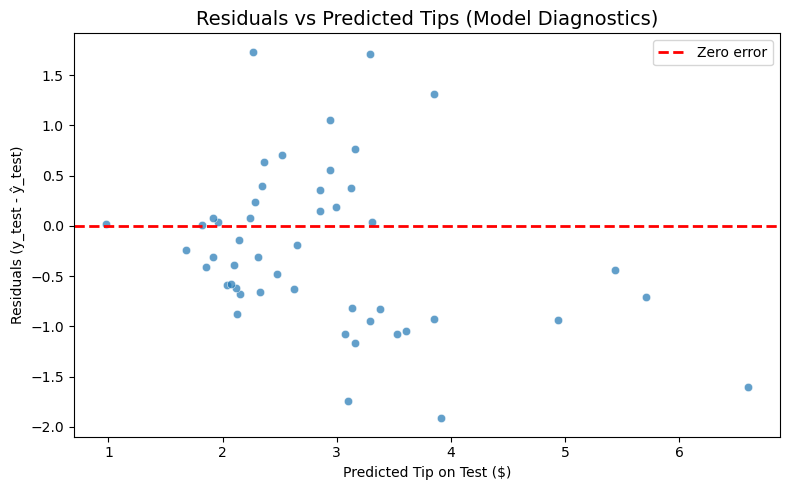

In [21]:
# --- Residuals vs Predicted Tips (Model Diagnostics) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1) Fit on full data (only if you haven't already fit on train)
X = df[["bill_total_usd", "party_size"]]
y = df["tip_usd"]

model = LinearRegression()
model.fit(X, y)

# 2) Handle both scenarios: with or without a test split
y_pred_full = model.predict(X)

# If you have y_test / X_test / y_pred_test defined elsewhere, use them; else use full data
try:
    # prefer test metrics if available
    y_pred = y_pred_test  # must be computed earlier from model.predict(X_test)
    residuals = y_test - y_pred
    x_for_plot = y_pred
    actual_label = "Residuals (y_test - ŷ_test)"
    pred_label = "Predicted Tip on Test ($)"
except NameError:
    # fallback: use full dataset
    y_pred = y_pred_full
    residuals = y - y_pred
    x_for_plot = y_pred
    actual_label = "Residuals (y - ŷ)"
    pred_label = "Predicted Tip ($)"

# 3) Plot residuals vs predicted
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=x_for_plot, y=residuals, alpha=0.7, ax=ax)

# reference line at 0
ax.axhline(0, color="red", linestyle="--", linewidth=2, label="Zero error")

ax.set_title("Residuals vs Predicted Tips (Model Diagnostics)", fontsize=14)
ax.set_xlabel(pred_label)
ax.set_ylabel(actual_label)
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
# Build a small DataFrame for logging/traceability
import pandas as pd
df_res = pd.DataFrame({
    "predicted_tip": x_for_plot,   # your x array (y_pred or y_pred_test)
    "residuals": residuals         # your residuals (y - y_pred or y_test - y_pred_test)
})

try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        ax,
        "reports/figures/residuals_vs_predicted_tips_model_diagnostics.png",  # avoid parentheses
        df=df_res,
        chart_type="scatter",              # this is a scatter, not a box/bar
        library="seaborn",
        x="predicted_tip",
        y="residuals",
        hue=None,                          # no hue here
        dataset_name="tips_encoded_or_clean",
        dataset_path="data/processed/tips_cleaned.csv",  # adjust if needed
        notebook="notebooks/05_Feature_Importance_and_Model_Refinement.ipynb",
        notes="Residuals vs predicted with zero-reference line; check randomness & variance.",
        timestamped=True
    )
    print("✅ Saved via save_and_log_plot")
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


✅ Saved Seaborn Axes figure to: reports/figures/residuals_vs_predicted_tips_model_diagnostics_2025-10-27_1624.png
📝 Logged metadata → reports/figures/residuals_vs_predicted_tips_model_diagnostics_2025-10-27_1624.json
✅ Saved via save_and_log_plot


#### Check residual normality (histogram + Q–Q plot)

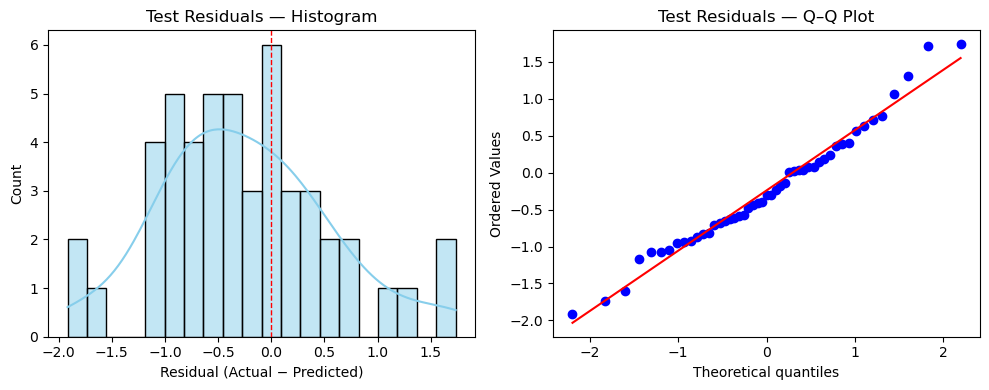

In [25]:
# --- Residual Normality: Histogram + Q–Q (auto uses test set if available) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Helper to coerce to 1D numpy arrays
def _to_1d(a):
    if isinstance(a, (pd.Series, pd.DataFrame)):
        a = a.values
    a = np.asarray(a)
    if a.ndim == 2 and a.shape[1] == 1:
        a = a.ravel()
    return a

# Prefer test split if it's already defined in your notebook; else use full data
use_test = False
try:
    _ = (X_test, y_test, y_pred_test)  # will NameError if not defined
    use_test = True
except NameError:
    use_test = False

if use_test:
    y_used   = _to_1d(y_test)
    yhat_used= _to_1d(y_pred_test)
    label_prefix = "Test"
else:
    # Fit/predict on full data if needed
    from sklearn.linear_model import LinearRegression
    X = df[["bill_total_usd", "party_size"]]
    y = df["tip_usd"]
    model = LinearRegression().fit(X, y)
    y_used    = _to_1d(y)
    yhat_used = _to_1d(model.predict(X))
    label_prefix = "Full"

# Sanity check lengths
if y_used.shape[0] != yhat_used.shape[0]:
    raise ValueError(f"Length mismatch: y has {y_used.shape[0]} rows, ŷ has {yhat_used.shape[0]} rows.")

# Residuals
residuals = y_used - yhat_used

# ---- Plots: Histogram + Q–Q ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1) Histogram + KDE
sns.histplot(residuals, bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title(f"{label_prefix} Residuals — Histogram")
axes[0].set_xlabel("Residual (Actual − Predicted)")
axes[0].axvline(0, color="red", linestyle="--", lw=1)

# 2) Q–Q plot against Normal
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title(f"{label_prefix} Residuals — Q–Q Plot")

plt.tight_layout()
plt.show()


In [26]:
# --- Build residuals DataFrame for logging ---
df_residuals = pd.DataFrame({
    "residuals": residuals,
    "predicted_tip": yhat_used
})

try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        fig,  # ✅ Use fig, not ax, since we plotted multiple subplots
        "reports/figures/residuals_normality_histogram_qqplot.png",
        df=df_residuals,
        chart_type="diagnostic",       # You can also label this "hist+qq" if you prefer
        library="matplotlib+seaborn",
        x="predicted_tip",
        y="residuals",
        dataset_name="tips_encoded_or_clean",
        dataset_path="data/processed/tips_cleaned.csv",
        notebook="notebooks/05_Residual_Normality_And_Model_Diagnostics.ipynb",
        notes="Residual histogram + Q–Q plot for checking normality assumption of linear regression residuals.",
        timestamped=True
    )
    print("✅ Saved via save_and_log_plot")
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


✅ Saved Matplotlib figure to: reports/figures/residuals_normality_histogram_qqplot_2025-10-27_1731.png
📝 Logged metadata → reports/figures/residuals_normality_histogram_qqplot_2025-10-27_1731.json
✅ Saved via save_and_log_plot


### 🧠 ELI5: Residual Normality (Histogram + Q–Q Plot) [☝️]

- These two charts help check if the model’s **errors (residuals)** behave like we expect — mostly random and roughly **bell-shaped**.
- **Histogram (left):**  
  - Bars show how often different error sizes occur.  
  - The red dashed line is **zero error** — where predictions are spot-on.  
  - The blue curve should look like a smooth hill (Normal distribution).  
  - If it’s lopsided or has long tails, errors aren’t evenly spread.
- **Q–Q Plot (right):**  
  - Each dot compares actual residuals to a “perfectly normal” theoretical model.  
  - If the dots hug the red line → errors are close to normal.  
  - If the dots curve away → there may be **skewness or outliers**.
- ✅ Why it matters: Linear regression assumes residuals are normally distributed; this helps ensure reliable confidence intervals and hypothesis tests.


#### Shapiro–Wilk test

In [27]:
from scipy.stats import shapiro

# --- Normality Test (Shapiro–Wilk) ---
stat, p_value = shapiro(residuals)

print("Shapiro–Wilk Normality Test:")
print(f"Statistic = {stat:.3f},  p-value = {p_value:.4f}")

# --- ELI5-style interpretation ---
if p_value > 0.05:
    print("\n✅ ELI5: Residuals look roughly normal — nothing weird here.")
    print("That means our model’s errors are random and symmetric, like we expect.")
else:
    print("\n⚠️ ELI5: Residuals deviate from normal — something’s off.")
    print("This could mean skewed errors, outliers, or a missing variable in the model.")


Shapiro–Wilk Normality Test:
Statistic = 0.978,  p-value = 0.4723

✅ ELI5: Residuals look roughly normal — nothing weird here.
That means our model’s errors are random and symmetric, like we expect.


### 🧠 ELI5: Fixing Heteroscedasticity

**Problem:**  
Heteroscedasticity means the **spread of residuals grows or shrinks** as predictions get bigger — like a cone-shaped cloud instead of an even scatter.  
That violates a core linear-regression rule: the errors should have **constant variance** (homoscedasticity).  
If it happens, our model’s uncertainty estimates (like confidence intervals) become unreliable.

**Fixes to Try:**

1. **Log Transform the Target (y)**  
   - If the target (e.g., tip_usd) grows with scale, take `np.log(y)` before fitting the model.  
   - This makes big values less extreme, evening out variance.  
   - After prediction, convert back with `np.exp(predictions)`.

2. **Box-Cox Transform (more flexible than log)**  
   - Fits a power transformation that best stabilizes variance.  
   - Example:
     ```python
     from scipy.stats import boxcox
     y_bc, lambda_bc = boxcox(y + 1e-6)  # add small offset to avoid log(0)
     ```
   - Use `inv_boxcox()` to convert predictions back to the original scale.

3. **Robust Regression**  
   - Ordinary least squares (OLS) gives *squared* penalties — so outliers and heteroscedastic points pull hard.  
   - Robust methods (like `HuberRegressor` or `RLM` in statsmodels) **downweight** large errors automatically.
   - Example:
     ```python
     from sklearn.linear_model import HuberRegressor
     model = HuberRegressor().fit(X, y)
     ```

**✅ Goal:**  
After transformation or robust fitting, the residuals should look random and equally spread — no funnel shapes.

**Visual sanity check:**  
Re-plot “Residuals vs Predicted” — if the scatter is roughly even around zero again, your fix worked.


Shapiro–Wilk (normality of residuals)
  OLS residuals:     stat=0.967, p=0.0000
  Log-OLS residuals: stat=0.997, p=0.9459
  ✅ Log-OLS looks more normal (compare p-values; >0.05 is typically 'normal enough').


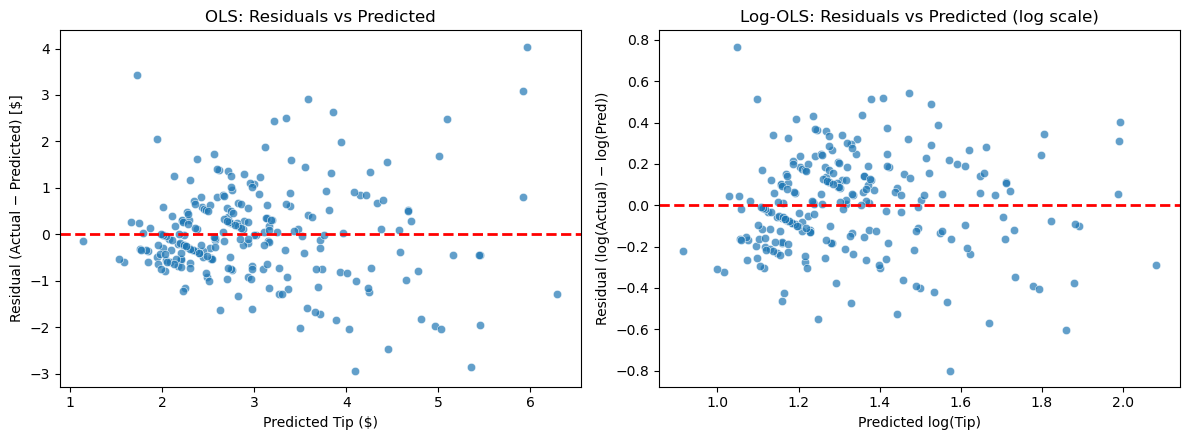

✅ Saved Matplotlib figure to: reports/figures/ols_vs_log_ols_residuals_side_by_side_2025-10-28_0501.png
📝 Logged metadata → reports/figures/ols_vs_log_ols_residuals_side_by_side_2025-10-28_0501.json
✅ Saved via save_and_log_plot


In [28]:
# --- Compare OLS vs Log-OLS: Residuals vs Predicted (side-by-side) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro

# ---- Inputs (expects df with these columns) ----
features = ["bill_total_usd", "party_size"]
target   = "tip_usd"
X = df[features].to_numpy()
y = df[target].to_numpy()

# ---------- Model A: Ordinary Least Squares on y ----------
ols = LinearRegression().fit(X, y)
yhat_ols = ols.predict(X)
resid_ols = y - yhat_ols

# ---------- Model B: OLS on log(y) (variance stabilizing) ----------
# Use log1p/expm1 for safety with zeros
y_log = np.log1p(y)
log_ols = LinearRegression().fit(X, y_log)
yhat_log = log_ols.predict(X)
# Residuals on log scale
resid_log = y_log - yhat_log

# Optional: back-transform log predictions if you want predictions on $ scale
yhat_log_back = np.expm1(yhat_log)

# ---------- Quick normality check (Shapiro–Wilk) ----------
stat_ols, p_ols = shapiro(resid_ols)
stat_log, p_log = shapiro(resid_log)

print("Shapiro–Wilk (normality of residuals)")
print(f"  OLS residuals:     stat={stat_ols:.3f}, p={p_ols:.4f}")
print(f"  Log-OLS residuals: stat={stat_log:.3f}, p={p_log:.4f}")
print(("  ✅ Log-OLS looks more normal" if p_log > p_ols else "  ℹ️ OLS looks at least as normal")
      + " (compare p-values; >0.05 is typically 'normal enough').")

# ---------- Plot residuals vs predicted for both ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

# Left: OLS residuals vs predicted ($ scale)
sns.scatterplot(x=yhat_ols, y=resid_ols, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color="red", ls="--", lw=2)
axes[0].set_title("OLS: Residuals vs Predicted")
axes[0].set_xlabel("Predicted Tip ($)")
axes[0].set_ylabel("Residual (Actual − Predicted) [$]")

# Right: Log-OLS residuals vs predicted (log scale)
sns.scatterplot(x=yhat_log, y=resid_log, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color="red", ls="--", lw=2)
axes[1].set_title("Log-OLS: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(Tip)")
axes[1].set_ylabel("Residual (log(Actual) − log(Pred))")

plt.tight_layout()
plt.show()

# ---------- Optional: save via your helper (with graceful fallback) ----------
try:
    from src.helpers import save_and_log_plot
    # make a small logging frame
    df_log = pd.DataFrame({
        "pred_tip_ols": yhat_ols,
        "resid_ols": resid_ols,
        "pred_tip_log": yhat_log,
        "resid_log": resid_log
    })
    save_and_log_plot(
        fig,
        "reports/figures/ols_vs_log_ols_residuals_side_by_side.png",
        df=df_log,
        chart_type="residuals_compare",
        library="matplotlib+seaborn",
        x="pred_tip_ols",
        y="resid_ols",
        dataset_name="tips_cleaned",
        dataset_path="data/processed/tips_cleaned.csv",
        notebook="notebooks/05_Heteroscedasticity_Fixes.ipynb",
        notes=f"Compare OLS vs log-OLS. Shapiro p (OLS)={p_ols:.4f}, (Log-OLS)={p_log:.4f}.",
        timestamped=True
    )
    print("✅ Saved via save_and_log_plot")
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


### 🧠 ELI5: Did the log transform help?

We fit two models:
- **OLS (normal)** predicts the tip directly in dollars.
- **Log-OLS** predicts the **log of the tip**, which shrinks big values and often evens out the spread of errors.

**How to read the plots:**
- Each chart shows **Residuals vs Predicted**.
- A healthy model has points **evenly scattered around the red 0-line** (no cone/funnel shapes).

**What to look for:**
- If the **OLS** plot looks like a funnel (spread grows with larger predictions), that’s **heteroscedasticity**.
- If the **Log-OLS** plot looks more evenly spread, the **log transform helped** stabilize variance.

**Quick stat check (printed above the plots):**
- We also ran the **Shapiro–Wilk** test for normality of residuals.
- A **higher p-value** (especially > 0.05) means “close enough to normal.”

**Bottom line:**
- If the **Log-OLS** residuals look more random and have a better (higher) normality p-value,
  you’ve reduced heteroscedasticity — great!  
- If not, consider other fixes (Box-Cox transform, adding missing features, or using robust regression).


#### Breusch–Pagan test

In [9]:
# --- Breusch–Pagan test (robust: numeric-only, aligned, float-cast) ---
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# 1) Choose features (add dummy creation if you want categoricals)
features = ["bill_total_usd", "party_size"]  # extend later if needed

# If you want to include gender/smoker, uncomment:
# df_bp = pd.get_dummies(df, columns=["gender", "is_smoker"], drop_first=True)
# else:
df_bp = df.copy()

# 2) Build numeric X, y and align/drop NaNs
X = df_bp[features].select_dtypes(include=[np.number]).copy()
y = df_bp["tip_usd"]

# keep only rows where both X and y are valid numbers
xy = pd.concat([X, y], axis=1).dropna()
X = xy[features].astype(float)
y = xy["tip_usd"].astype(float)

# 3) Add constant & fit OLS in statsmodels (requires float arrays)
X_const = sm.add_constant(X, has_constant="add")
ols_model = sm.OLS(y.values.astype(float), X_const.values.astype(float)).fit()

# 4) Breusch–Pagan on residuals vs regressors
bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(ols_model.resid, X_const.values.astype(float))

print("Breusch–Pagan test results:")
print(f"  LM statistic : {bp_stat:.4f}")
print(f"  LM p-value   : {bp_pval:.4f}")
print(f"  F statistic  : {f_stat:.4f}")
print(f"  F p-value    : {f_pval:.4f}")

# ELI5 interpretation
if bp_pval > 0.05:
    print("\n✅ ELI5: Residuals show roughly constant spread (homoscedastic).")
else:
    print("\n⚠️ ELI5: Residuals show uneven spread (heteroscedastic).")
    print("Try log/Box–Cox transform of the target or robust regression.")


Breusch–Pagan test results:
  LM statistic : 48.1520
  LM p-value   : 0.0000
  F statistic  : 29.6266
  F p-value    : 0.0000

⚠️ ELI5: Residuals show uneven spread (heteroscedastic).
Try log/Box–Cox transform of the target or robust regression.


### 🧠 ELI5: Breusch–Pagan Test — Are Residuals Even?

The **Breusch–Pagan (BP)** test checks whether your model’s residuals  
have a **constant spread** (homoscedasticity) or **uneven spread** (heteroscedasticity).

**What it does:**
- It looks for a pattern between the **size of the errors** and the **size of the predictions**.
- A pattern (p < 0.05) → bad → heteroscedasticity.
- No pattern (p > 0.05) → good → homoscedasticity.

**Interpretation:**
- ✅ **p > 0.05** → Residuals are evenly spread. Your model is fine.  
- ⚠️ **p < 0.05** → Residuals’ variance changes with prediction size.
  Try:
  - Logging or Box–Cox transforming the target  
  - Using a **robust regression** (e.g., Huber or RLM)

**Why it matters:**  
If the model’s errors grow with bigger predictions, confidence intervals and hypothesis tests  
can become unreliable — the model “trusts” big predictions too much.


In [12]:
# --- Robust dummy creation for BP test ---
df_bp = df.copy()

# Only create dummies if columns are present
cols_to_encode = [col for col in ["gender", "is_smoker"] if col in df_bp.columns]

if cols_to_encode:
    df_bp = pd.get_dummies(df_bp, columns=cols_to_encode, prefix=cols_to_encode, drop_first=True)

# --- Choose numeric predictors that now exist ---
features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"] if c in df_bp.columns]
print("Features used:", features)


Features used: ['bill_total_usd', 'party_size', 'gender_Male']


In [18]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X = df_bp[features].astype(float)
y = df_bp["tip_usd"].astype(float)

# Add constant term (intercept)
X_const = sm.add_constant(X, has_constant="add")

# Fit OLS model
ols_model = sm.OLS(y, X_const).fit()

# Run Breusch–Pagan test
bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(ols_model.resid, X_const)

print(f"LM Stat: {bp_stat:.3f}, p={bp_pval:.4f}")
print("Breusch–Pagan test results with get_dummies:")
print(f"  LM statistic : {bp_stat:.4f}")
print(f"  LM p-value   : {bp_pval:.4f}")
print(f"  F statistic  : {f_stat:.4f}")
print(f"  F p-value    : {f_pval:.4f}")

if bp_pval > 0.05:
    print("✅ ELI5: Residuals have constant variance (homoscedastic).")
else:
    print("⚠️ ELI5: Residuals show uneven variance (heteroscedastic). Try log or robust regression.")


LM Stat: 49.014, p=0.0000
Breusch–Pagan test results with get_dummies:
  LM statistic : 49.0145
  LM p-value   : 0.0000
  F statistic  : 20.1100
  F p-value    : 0.0000
⚠️ ELI5: Residuals show uneven variance (heteroscedastic). Try log or robust regression.


### 🧮 Breusch–Pagan Test for Heteroscedasticity (with Safe Dummy Handling) ☝️☝️☝️

We’ll test whether the residuals of our regression have **constant variance** (homoscedasticity)  
or **uneven variance** (heteroscedasticity). This matters because unequal variance can make  
our model’s estimates unreliable, especially for larger predictions.


=== Metrics ===
OLS ($):           R²=0.468  RMSE=$1.007
Log-OLS (back $):  R²=0.456  RMSE=$1.018

=== Shapiro–Wilk Normality (residuals) ===
OLS residuals ( $ ):       stat=0.967, p=0.0000
Log-OLS residuals (log):   stat=0.997, p=0.9459  (higher p ⇒ more normal)

=== Breusch–Pagan Heteroscedasticity ===
OLS:     LM p-value=0.0000  (p>0.05 ⇒ constant variance)
Log-OLS: LM p-value=0.0035  (on log scale)

✅ ELI5: Residuals look more normal after log transform.
✅ ELI5: Heteroscedasticity signal is weaker after log transform (better).


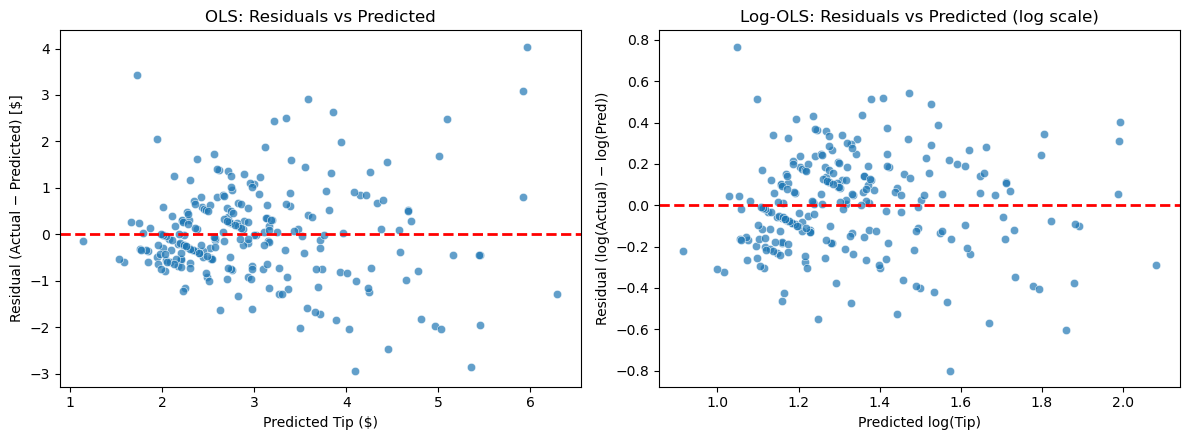

In [21]:
# --- OLS vs Log-OLS: before/after comparison with diagnostics ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# -------------------- Data --------------------
features = ["bill_total_usd", "party_size"]
target   = "tip_usd"

# numeric-only, aligned, drop NaNs
xy = df[features + [target]].select_dtypes(include=[np.number]).dropna().copy()
X = xy[features].to_numpy(dtype=float)
y = xy[target].to_numpy(dtype=float)

# -------------------- Model A: OLS on y ($) --------------------
ols = LinearRegression().fit(X, y)
yhat_ols = ols.predict(X)
resid_ols = y - yhat_ols

# Metrics (in $)  # does not work with scikit-learn < 0.22
# rmse_ols = mean_squared_error(y, yhat_ols, squared=False)

rmse_ols = np.sqrt(mean_squared_error(y, yhat_ols))
r2_ols   = r2_score(y, yhat_ols)
sh_stat_ols, sh_p_ols = shapiro(resid_ols)

# BP test (requires statsmodels OLS)
X_const = sm.add_constant(X, has_constant="add")
sm_ols = sm.OLS(y, X_const).fit()
bp_stat_ols, bp_p_ols, bp_f_ols, bp_fp_ols = het_breuschpagan(sm_ols.resid, X_const)

# -------------------- Model B: OLS on log(y) --------------------
# Use log1p/expm1 for safety (handles zeros)
y_log = np.log1p(y)
log_ols = LinearRegression().fit(X, y_log)
yhat_log = log_ols.predict(X)
resid_log = y_log - yhat_log

# Back-transform predictions to $ for interpretability
yhat_log_back = np.expm1(yhat_log)

# Metrics (report on $ scale for comparability)  Does not work with scikit-learn < 0.22
# rmse_log_back = mean_squared_error(y, yhat_log_back, squared=False)

rmse_log_back = np.sqrt(mean_squared_error(y, yhat_log_back))
r2_log_back   = r2_score(y, yhat_log_back)
sh_stat_log, sh_p_log = shapiro(resid_log)  # normality on log scale (what the model fits)

# BP test for log model (on log scale, consistent with fit)
sm_log = sm.OLS(y_log, X_const).fit()
bp_stat_log, bp_p_log, bp_f_log, bp_fp_log = het_breuschpagan(sm_log.resid, X_const)

# -------------------- Print summary --------------------
print("=== Metrics ===")
print(f"OLS ($):           R²={r2_ols:.3f}  RMSE=${rmse_ols:.3f}")
print(f"Log-OLS (back $):  R²={r2_log_back:.3f}  RMSE=${rmse_log_back:.3f}\n")

print("=== Shapiro–Wilk Normality (residuals) ===")
print(f"OLS residuals ( $ ):       stat={sh_stat_ols:.3f}, p={sh_p_ols:.4f}")
print(f"Log-OLS residuals (log):   stat={sh_stat_log:.3f}, p={sh_p_log:.4f}  (higher p ⇒ more normal)\n")

print("=== Breusch–Pagan Heteroscedasticity ===")
print(f"OLS:     LM p-value={bp_p_ols:.4f}  (p>0.05 ⇒ constant variance)")
print(f"Log-OLS: LM p-value={bp_p_log:.4f}  (on log scale)\n")

# Quick ELI5 one-liners
if sh_p_log > sh_p_ols:
    print("✅ ELI5: Residuals look more normal after log transform.")
else:
    print("ℹ️ ELI5: Log transform did not improve residual normality vs OLS.")

if bp_p_log > bp_p_ols:
    print("✅ ELI5: Heteroscedasticity signal is weaker after log transform (better).")
else:
    print("ℹ️ ELI5: Log transform did not reduce heteroscedasticity vs OLS.")

# -------------------- Side-by-side residual plots --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: OLS residuals vs predicted ($ scale)
sns.scatterplot(x=yhat_ols, y=resid_ols, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color="red", ls="--", lw=2)
axes[0].set_title("OLS: Residuals vs Predicted")
axes[0].set_xlabel("Predicted Tip ($)")
axes[0].set_ylabel("Residual (Actual − Predicted) [$]")

# Right: Log-OLS residuals vs predicted (log scale)
sns.scatterplot(x=yhat_log, y=resid_log, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color="red", ls="--", lw=2)
axes[1].set_title("Log-OLS: Residuals vs Predicted (log scale)")
axes[1].set_xlabel("Predicted log(Tip)")
axes[1].set_ylabel("Residual (log(Actual) − log(Pred))")

plt.tight_layout()
plt.show()

# # -------------------- Optional: save via your helper --------------------
# try:
#     from src.helpers import save_and_log_plot
#     df_diag = pd.DataFrame({
#         "pred_tip_ols": yhat_ols,
#         "resid_ols": resid_ols,
#         "pred_log": yhat_log,
#         "resid_log": resid_log
#     })
#     save_and_log_plot(
#         fig,
#         "reports/figures/ols_vs_log_ols_residuals_side_by_side.png",
#         df=df_diag,
#         chart_type="residuals_compare",
#         library="matplotlib+seaborn",
#         x="pred_tip_ols",
#         y="resid_ols",
#         dataset_name="tips_cleaned",
#         dataset_path="data/processed/tips_cleaned.csv",
#         notebook="notebooks/05_Heteroscedasticity_Fixes.ipynb",
#         notes=(f"Shapiro p OLS={sh_p_ols:.4f}, Log={sh_p_log:.4f}; "
#                f"BP p OLS={bp_p_ols:.4f}, Log={bp_p_log:.4f}. "
#                "Log model often stabilizes variance."),
#         timestamped=True
#     )
#     print("✅ Saved via save_and_log_plot")
# except Exception as e:
#     print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


🧠 ELI5: ☝️☝️☝️
`mean_squared_error()` gives us the average of squared errors.  
Older versions of scikit-learn didn’t include the `squared=False` option (which directly gives RMSE).  
So, we just take the square root ourselves using NumPy — that’s the same as setting `squared=False` in newer versions.


In [22]:

# -------------------- Optional: save via your helper --------------------
try:
    from src.helpers import save_and_log_plot
    df_diag = pd.DataFrame({
        "pred_tip_ols": yhat_ols,
        "resid_ols": resid_ols,
        "pred_log": yhat_log,
        "resid_log": resid_log
    })
    save_and_log_plot(
        fig,
        "reports/figures/ols_vs_log_ols_residuals_side_by_side.png",
        df=df_diag,
        chart_type="residuals_compare",
        library="matplotlib+seaborn",
        x="pred_tip_ols",
        y="resid_ols",
        dataset_name="tips_cleaned",
        dataset_path="data/processed/tips_cleaned.csv",
        notebook="notebooks/05_Heteroscedasticity_Fixes.ipynb",
        notes=(f"Shapiro p OLS={sh_p_ols:.4f}, Log={sh_p_log:.4f}; "
               f"BP p OLS={bp_p_ols:.4f}, Log={bp_p_log:.4f}. "
               "Log model often stabilizes variance."),
        timestamped=True
    )
    print("✅ Saved via save_and_log_plot")
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

✅ Saved Matplotlib figure to: reports/figures/ols_vs_log_ols_residuals_side_by_side_2025-10-28_1642.png
📝 Logged metadata → reports/figures/ols_vs_log_ols_residuals_side_by_side_2025-10-28_1642.json
✅ Saved via save_and_log_plot
